23070521135 - Sharvayu Zade

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [6]:
data = pd.read_csv(r"E:\Sharvayu data\Malware\Symbiosis Nagpur SIT\7th SEM\DL LAB\DeepLearning LAB\Practical 3\WA_Fn-UseC_-Telco-Customer-Churn.csv")
data.columns = data.columns.str.strip().str.lower()
data.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [12]:
# Remove customer ID if present
if "customerid" in data.columns:
    data = data.drop("customerid", axis=1)

# Convert the target to numeric labels
data["churn"] = data["churn"].str.strip().str.lower().map({"no": 0, "yes": 1})

# One-hot encode every remaining categorical feature except the target
categorical_columns = [
    column_name
    for column_name in data.select_dtypes(include=["object"]).columns
    if column_name != "churn"
]
data = pd.get_dummies(data, columns=categorical_columns)

# Separate features and target
X = data.drop("churn", axis=1)
y = data["churn"]

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 5634
Testing Samples: 1409


In [16]:
model = Sequential()

model.add(Dense(32, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

model.summary()

e:\Sharvayu data\Malware\Symbiosis Nagpur SIT\7th SEM\DL LAB\DeepLearning LAB\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 32)             │       210,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,105 (824.63 KB)

 Trainable params: 211,105 (824.63 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully")

Model Compiled Successfully


In [18]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=4,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7850 - loss: 0.4555 - val_accuracy: 0.8012 - val_loss: 0.4227
Epoch 2/50
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7992 - loss: 0.4288 - val_accuracy: 0.7711 - val_loss: 0.4447
Epoch 3/50
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8056 - loss: 0.4151 - val_accuracy: 0.8110 - val_loss: 0.4064
Epoch 4/50
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8207 - loss: 0.3969 - val_accuracy: 0.7622 - val_loss: 0.5037
Epoch 5/50
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.8296 - loss: 0.3752 - val_accuracy: 0.7906 - val_loss: 0.4338
Epoch 6/50
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8638 - loss: 0.3132 - val_accuracy: 0.7640 - val_loss: 0.4656
Epoch 7/50
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9274 - loss: 0.1993 - val_accuracy: 0.7347 - val_loss: 0.5392
Epoch 8/50
1127/1127 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9621 - loss: 0.1138

In [ ]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step - accuracy: 1.0000 - loss: 0.0504
Test Loss: 0.050392553210258484
Test Accuracy: 1.0


In [ ]:
predictions = model.predict(X_test)

predictions = (predictions > 0.5).astype(int)

print("Predicted Values:")
print(predictions.flatten())

print("\nActual Values:")
print(y_test.values)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
Predicted Values:
[1 0 0 0]

Actual Values:
[1 0 0 0]


In [ ]:
print("Accuracy:", accuracy_score(y_test, predictions))

print("\nClassification Report")
print(classification_report(y_test, predictions))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, predictions))

Accuracy: 1.0

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         1

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4


Confusion Matrix
[[3 0]
 [0 1]]


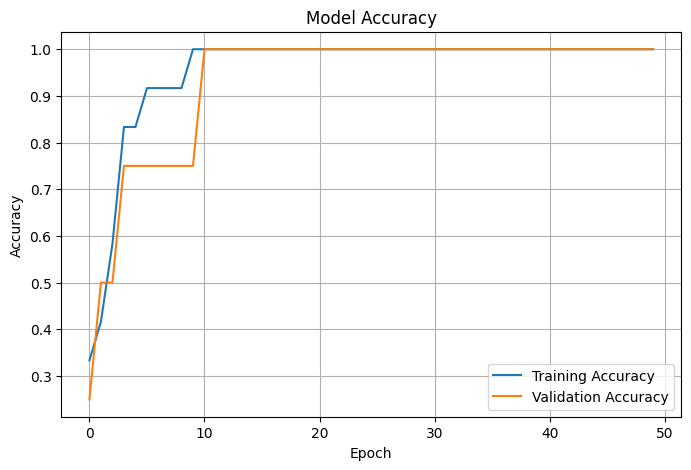

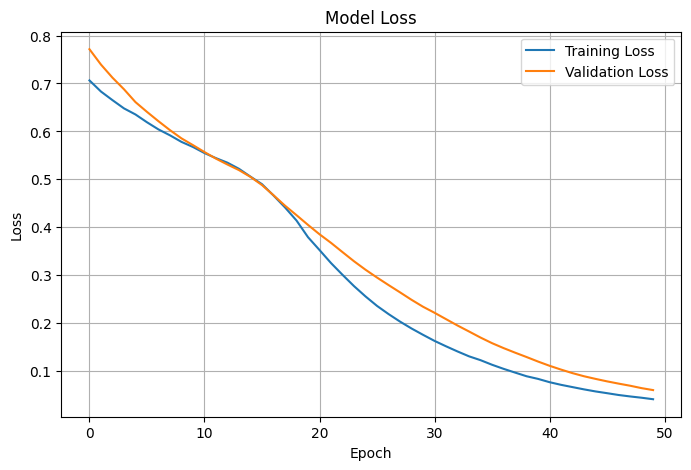

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.legend()
plt.grid(True)
plt.show()